In [ ]:
import os

# keep caches off HOME if you've set that up
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")  # force JAX to CPU
# (optional) match CPU threads to your allocation
os.environ.setdefault("OMP_NUM_THREADS", os.environ.get("SLURM_CPUS_PER_TASK", "4"))

'4'

In [ ]:
import torch, jax

key = jax.random.PRNGKey(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")
print(
    "Torch device:",
    device,
    "| CUDA available:",
    torch.cuda.is_available(),
    "CUDA:",
    torch.version.cuda,
)
print("JAX backend:", jax.default_backend())

Torch device: cuda | CUDA available: True CUDA: 12.4
JAX backend: cpu


In [3]:
if torch.cuda.is_available():
    total = torch.cuda.get_device_properties(0).total_memory
    try:
        free, total2 = torch.cuda.mem_get_info()
        # total2 should match total; if not, keep 'total'
    except AttributeError:
        free = total - torch.cuda.memory_reserved(0)
    print(f"Total VRAM: {total/1024**2:.2f} MB | Free (driver): {free/1024**2:.2f} MB")
else:
    print("No GPU available.")

Total VRAM: 45518.25 MB | Free (driver): 45249.88 MB


In [ ]:
# core libs
import os, time
import jax.numpy as jnp
import jax.lax as lax
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from math import sqrt, pi, exp
from tqdm.auto import tqdm

# your vehicle model pieces
from simulation.VehicleModel import (
    default_params,
    vehicle_RK4x,
    vehicle_fy,
    radius_tire,
)

import torch.nn as nn
import sbi
from sbi import utils as sbi_utils
from sbi import inference as sbi_inference
from sbi.utils.simulation_utils import simulate_for_sbi
from sbi.neural_nets.factory import posterior_nn

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [ ]:
# --- Multi-trajectory config ---
dt = 0.01  # time step
T_seg = 3000  # steps per segment (~30 s at 100 Hz)
DECIMATE = 2  # downsample factor to lighten GRU load; set 1 to disable

In [ ]:
@jax.jit
def rollout_with_states(p, controls, state0=None):
    """
    Returns:
      state_seq: (T, state_dim)
      y_seq    : (T, d)
    """
    T_local = controls["steer_ang"].shape[0]
    if state0 is None:
        state0 = jnp.zeros(10, dtype=jnp.float32)

    def body_fn(state, t):
        u_t = {k: v[t] for k, v in controls.items()}
        state_next = vehicle_RK4x(state, u_t, p, **default_params)
        y_t = vehicle_fy(state_next, u_t, p, **default_params)
        return state_next, (state_next, y_t)

    t_idx = jnp.arange(T_local, dtype=jnp.int32)
    _, (state_seq, y_seq) = lax.scan(body_fn, state0, t_idx)
    return state_seq, y_seq  # (T, state_dim), (T, d)


def controls_to_array(ctrls):
    # Keep order fixed and consistent everywhere
    return jnp.stack(
        [
            ctrls["steer_ang"],
            ctrls["engine_torque"],
            ctrls["break_torque"],  # note: spelled 'break' in model API
            ctrls["gear_transmission"],
        ],
        axis=-1,
    )  # (T, 4)


def decimate_np(arr, factor):
    if factor <= 1:
        return arr
    L = (arr.shape[0] // factor) * factor
    return arr[:L:factor]

In [ ]:
def u_flat(T, value=0.0, *, dtype=np.float32):
    x = np.empty(T, dtype=dtype)
    x.fill(value)
    return x


def u_step(T, value=1.0, t_on=0, t_off=None, *, dtype=np.float32):
    """
    One rectangular step within the block.
    t_on / t_off are *sample indices* in [0, T].
    """
    x = np.zeros(T, dtype=dtype)
    if t_off is None:
        t_off = T
    t_on = int(np.clip(t_on, 0, T))
    t_off = int(np.clip(t_off, 0, T))
    if t_off > t_on:
        x[t_on:t_off] = value
    return x


def u_sine(T, amp=1.0, freq_hz=0.5, dt=0.01, phase=0.0, *, dtype=np.float32):
    t = np.arange(T, dtype=dtype) * dt
    return (amp * np.sin(2 * np.pi * freq_hz * t + phase)).astype(dtype)


def _one_rollout(p, s0, ctrls):
    return rollout_with_states(p, ctrls, state0=s0)[1]


# jit + vmap once at module level
_batched_rollout = jax.jit(jax.vmap(_one_rollout, in_axes=(0, 0, None)))


def _vmapped_rollout_train(P, S0, ctrls):
    return _batched_rollout(P, S0, ctrls)

In [ ]:
def _mk_signal(kind, T, dt, **kw):
    if kind == "flat":
        return u_flat(T, **kw)
    if kind == "step":
        return u_step(T, **kw)
    if kind == "sine":
        return u_sine(T, dt=dt, **kw)
    raise ValueError(f"unknown kind {kind}")


def _prepare_step_kwargs(kw, T_block, dt):
    """
    Allow user-friendly step specs inside a block:
      - duty ∈ (0,1]: fraction of the block ON, starting at t=0
      - t_on_s / t_off_s: times in seconds (converted to indices)
      - OR provide t_on / t_off directly as indices.
    """
    kw = dict(kw)  # copy
    if "duty" in kw:
        duty = float(kw.pop("duty"))
        on = 0
        off = max(1, int(round(duty * T_block)))
        kw["t_on"], kw["t_off"] = on, off
    else:
        if "t_on_s" in kw:
            kw["t_on"] = int(round(kw.pop("t_on_s") / dt))
        if "t_off_s" in kw:
            off_s = kw.pop("t_off_s")
            kw["t_off"] = None if off_s is None else int(round(off_s / dt))
    return kw


def controls_from_blocks(blocks, *, T_seg, dt, gear_default=3, ramp_s=0.0):
    """
    blocks: list of dicts, each like:
      {
        "dur_s": 3.0,
        "steer":  ("sine", {"amp": rad(5), "freq_hz": 0.7}),
        "engine": ("step", {"value": 220.0, "duty": 1.0}),   # step ON entire block
        "brake":  ("step", {"value": 280.0, "duty": 0.6}),   # <-- step brake (exciting)
        "gear":   ("flat", {"value": 4}),
      }
    Returns: dict of jnp arrays of length T_seg for the four controls.
    """
    segs = []
    left = T_seg
    for b in blocks:
        T_b = min(max(1, int(round(b["dur_s"] / dt))), left)

        def build_one(spec, default_kind, default_kw):
            kind, kw = spec if spec is not None else (default_kind, default_kw)
            if kind == "step":
                kw = _prepare_step_kwargs(kw, T_b, dt)
            return _mk_signal(kind, T_b, dt, **kw).astype(np.float32)

        steer = build_one(b.get("steer"), "flat", {"value": 0.0})
        eng = build_one(b.get("engine"), "flat", {"value": 0.0})
        brk = build_one(b.get("brake"), "flat", {"value": 0.0})
        gear = build_one(b.get("gear"), "flat", {"value": gear_default})

        segs.append((steer, eng, brk, gear))
        left -= T_b
        if left <= 0:
            break

    # pad to exact T_seg with flats (if needed)
    if left > 0:
        segs.append(
            (
                u_flat(left, 0.0),
                u_flat(left, 0.0),
                u_flat(left, 0.0),
                u_flat(left, gear_default),
            )
        )

    steer = np.concatenate([s for s, _, _, _ in segs], axis=0)[:T_seg]
    eng = np.concatenate([e for _, e, _, _ in segs], axis=0)[:T_seg]
    brk = np.concatenate([b for _, _, b, _ in segs], axis=0)[:T_seg]
    gear = np.concatenate([g for _, _, _, g in segs], axis=0)[:T_seg]

    # optional gentle ramps at block boundaries
    if ramp_s > 0.0:
        n = max(2, int(round(ramp_s / dt)))

        def ramp(vec):
            out = vec.copy()
            idx = 0
            for s, e, b, g in segs:
                L = len(s)
                if idx > 0:
                    a0, a1 = out[idx - 1], out[idx]
                    out[idx : idx + min(n, L)] = np.linspace(
                        a0, a1, num=min(n, L), dtype=np.float32
                    )
                idx += L
            return out

        steer = ramp(steer)
        eng = ramp(eng)
        brk = ramp(brk)

    return {
        "steer_ang": jnp.asarray(steer),
        "engine_torque": jnp.asarray(eng),
        "break_torque": jnp.asarray(brk),
        "gear_transmission": jnp.asarray(gear),
    }

In [ ]:
def rand_block_accel(rng):
    eng = float(rng.uniform(150, 300))
    duty = float(rng.uniform(0.4, 1.0))
    steer_deg = float(rng.uniform(4, 12))
    f = float(rng.uniform(0.5, 1.5))
    dur = float(rng.uniform(1.5, 4.0))
    gear = int(rng.integers(2, 6))
    return {
        "dur_s": dur,
        "engine": ("step", {"value": eng, "duty": duty}),
        "brake": ("step", {"value": 0.0, "duty": 0.0}),
        "steer": ("sine", {"amp": np.deg2rad(steer_deg), "freq_hz": f, "phase": 0.0}),
        "gear": ("flat", {"value": gear}),
    }


def rand_block_brake(rng):
    brk = float(rng.uniform(180, 380))
    duty = float(rng.uniform(0.2, 1.0))
    dur = float(rng.uniform(0.6, 3.0))
    gear = int(rng.integers(2, 6))
    return {
        "dur_s": dur,
        "engine": ("step", {"value": 0.0, "duty": 0.0}),
        "brake": ("step", {"value": brk, "duty": duty}),
        "steer": ("flat", {"value": 0.0}),
        "gear": ("flat", {"value": gear}),
    }


def rand_block_coast(rng):
    dur = float(rng.uniform(0.8, 2.5))
    steer_deg = float(rng.uniform(-2, 2))
    gear = int(rng.integers(2, 6))
    return {
        "dur_s": dur,
        "engine": ("step", {"value": 0.0, "duty": 0.0}),
        "brake": ("step", {"value": 0.0, "duty": 0.0}),
        "steer": ("flat", {"value": np.deg2rad(steer_deg)}),
        "gear": ("flat", {"value": gear}),
    }


def make_shuffled_U(rng, total_T, dt):
    pieces = []
    for _ in range(12):
        pieces.append(rand_block_accel(rng))
        pieces.append(rand_block_brake(rng))
        pieces.append(rand_block_coast(rng))
    rng.shuffle(pieces)
    blocks, tsum = [], 0.0
    for b in pieces:
        blocks.append(b)
        tsum += b["dur_s"]
        if tsum >= total_T * dt:
            break
    return blocks

In [ ]:
def plot_controls_only(ctrls, dt, title="Generated controls"):
    t = np.arange(int(ctrls["steer_ang"].shape[0])) * dt
    steer = np.rad2deg(np.asarray(ctrls["steer_ang"]))
    eng = np.asarray(ctrls["engine_torque"])
    brk = np.asarray(ctrls["break_torque"])
    gear = np.asarray(ctrls["gear_transmission"])

    fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(title)

    axs[0].plot(t, eng)
    axs[0].set_ylabel("engine [Nm]")
    axs[1].plot(t, brk)
    axs[1].set_ylabel("brake [arb]")
    axs[2].plot(t, steer)
    axs[2].set_ylabel("steer [deg]")
    axs[3].step(t, gear, where="post")
    axs[3].set_ylabel("gear")
    axs[3].set_xlabel("t [s]")
    plt.tight_layout()
    plt.show()

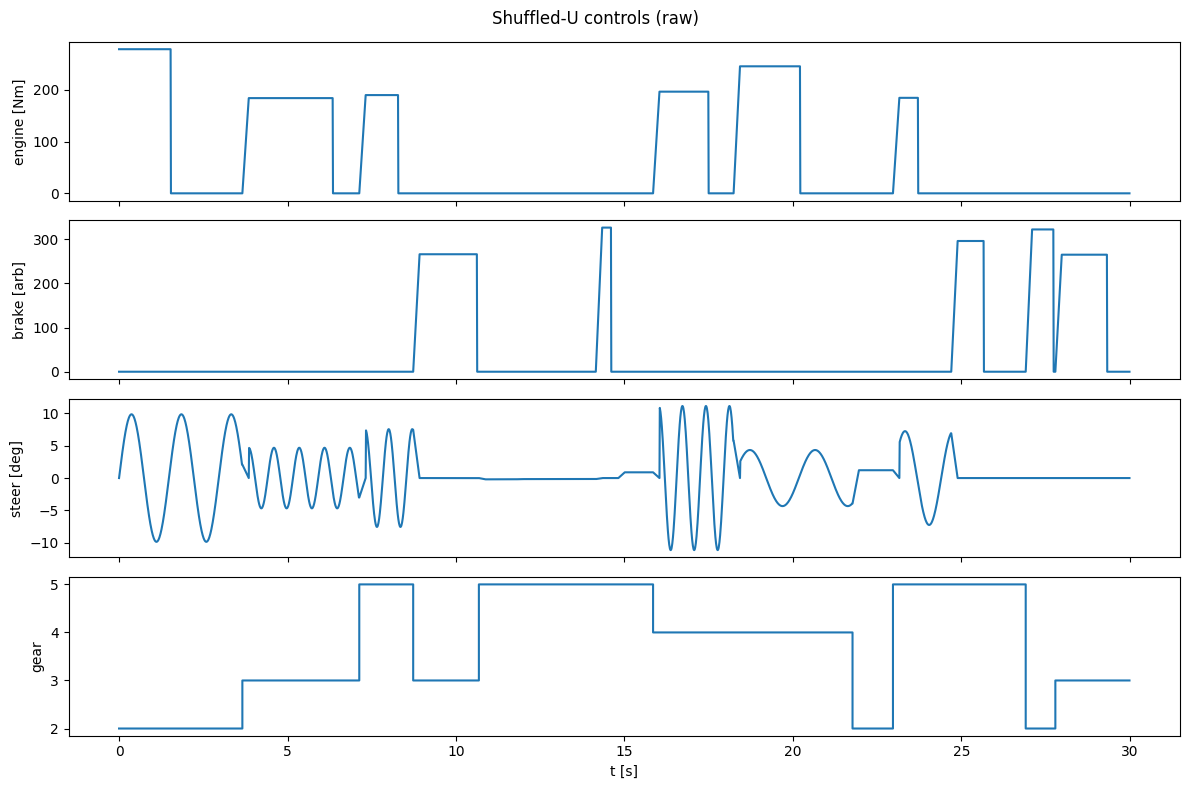

In [ ]:
rng = np.random.default_rng(0)
recipe = make_shuffled_U(rng, T_seg, dt)
ctrls = controls_from_blocks(recipe, T_seg=T_seg, dt=dt, ramp_s=0.2)
plot_controls_only(ctrls, dt, "Shuffled-U controls (raw)")

In [16]:
param_dim = 3
prior = sbi_utils.BoxUniform(
    low=torch.tensor([0.50, 0.05, 1200.0], dtype=torch.float32, device=device),
    high=torch.tensor([1.50, 0.60, 2200.0], dtype=torch.float32, device=device),
)

In [ ]:
prior_mid = (prior.base_dist.low + prior.base_dist.high) * 0.5
STATE_DIM = 10
KMH_TO_MS = 1.0 / 3.6

In [ ]:
# Discrete speed grid: 10, 20, ..., 100 km/h in m/s
INIT_SPEEDS_MS = np.arange(10.0, 110.0, 10.0, dtype=np.float32) * KMH_TO_MS


def sample_initial_states(rng: np.random.Generator, B: int) -> jnp.ndarray:
    """
    Sample a batch of B initial states with:
      - v_x from 10–100 km/h (discrete grid)
      - small random lateral velocity
      - small random yaw / yaw rate
      - wheel speeds roughly consistent with v_x
      - geo_pos = 0
    Returns: S0 of shape (B, STATE_DIM) as jnp.float32.
    """
    # 1) Choose speeds from the grid
    idx = rng.integers(0, len(INIT_SPEEDS_MS), size=B)
    v_x0 = INIT_SPEEDS_MS[idx]  # (B,)

    # 2) Lateral velocity: small spread (e.g. -1..1 m/s)
    v_y0 = rng.uniform(-1.0, 1.0, size=B).astype(np.float32)

    # 3) Yaw and yaw rate: small angles/rates
    yaw0 = rng.uniform(-0.05, 0.05, size=B).astype(np.float32)  # ~±3°
    dyaw0 = rng.uniform(-0.2, 0.2, size=B).astype(np.float32)  # rad/s

    # 4) Tire rates: approximate from v_x and wheel radius
    # If your params have a wheel radius, use that; otherwise choose a reasonable default.
    R_wheel = radius_tire  # meters
    base_omega = v_x0 / max(R_wheel, 1e-6)  # rad/s

    # Add small variation per wheel (optional)
    noise_scale = 0.05  # 5% noise
    tire_fl = base_omega * (
        1.0 + rng.normal(0.0, noise_scale, size=B).astype(np.float32)
    )
    tire_fr = base_omega * (
        1.0 + rng.normal(0.0, noise_scale, size=B).astype(np.float32)
    )
    tire_rl = base_omega * (
        1.0 + rng.normal(0.0, noise_scale, size=B).astype(np.float32)
    )
    tire_rr = base_omega * (
        1.0 + rng.normal(0.0, noise_scale, size=B).astype(np.float32)
    )

    # 5) Geo position: start at origin
    geo_pos_x = np.zeros(B, dtype=np.float32)
    geo_pos_y = np.zeros(B, dtype=np.float32)

    # 6) Stack into (B, 10) following the state layout used in vehicle_fy
    state_np = np.stack(
        [
            geo_pos_x,
            geo_pos_y,  # 0:2
            yaw0,  # 2
            dyaw0,  # 3
            v_x0,
            v_y0,  # 4:6
            tire_fl,
            tire_fr,
            tire_rl,
            tire_rr,  # 6:10
        ],
        axis=1,
    ).astype(np.float32)

    return jnp.asarray(state_np, dtype=jnp.float32)

In [ ]:
def simulator(theta: torch.Tensor) -> torch.Tensor:
    theta_np = theta.detach().cpu().numpy().astype(np.float32)
    B = theta_np.shape[0]

    rng = np.random.default_rng(getattr(simulator, "_batch_idx", 0) + RANDOM_SEED)
    simulator._batch_idx = getattr(simulator, "_batch_idx", 0) + 1

    recipe = make_shuffled_U(rng, T_seg, dt)
    ctrls = controls_from_blocks(recipe, T_seg=T_seg, dt=dt, ramp_s=0.2)

    # S0 = jnp.zeros((B, STATE_DIM), dtype=jnp.float32)  # (B, STATE_DIM)
    S0 = sample_initial_states(rng, B)  # (B, STATE_DIM)

    P = jnp.asarray(theta_np, dtype=jnp.float32)
    y_batch = _vmapped_rollout_train(P, S0, ctrls)  # (B, T_seg, d)

    c = controls_to_array(ctrls)
    c_rep = jnp.broadcast_to(c, (B, c.shape[0], c.shape[1]))
    yc = jnp.concatenate([y_batch, c_rep], axis=-1)

    if DECIMATE > 1:
        L = (yc.shape[1] // DECIMATE) * DECIMATE
        yc = yc[:, :L:DECIMATE, :]

    return torch.from_numpy(np.asarray(yc, np.float32))

In [ ]:
def generate_dataset(prior, N, batch=512, show_pbar=True, jit_warmup=True):
    """
    Vectorized, batched simulator with a progress bar + ETA.
    Returns: (theta_all, x_all) on CPU.
    """
    Theta, X = [], []

    # One-time JAX compile so the bar doesn't 'hang' on the first batch
    if jit_warmup:
        if show_pbar:
            tqdm.write("Compiling JAX (one-time JIT warmup)…")
        with torch.inference_mode():
            theta_w = prior.sample((min(8, N),)).to("cpu")
            _ = simulator(theta_w)  # triggers JIT

    pbar = None
    if show_pbar:
        pbar = tqdm(
            total=N,
            unit="sims",
            desc="Generating sims",
            dynamic_ncols=True,
            smoothing=0.1,
        )

    done = 0
    t0 = time.time()

    with torch.inference_mode():
        for i in range(0, N, batch):
            b = min(batch, N - i)
            theta_b = prior.sample((b,)).to("cpu")
            x_b = simulator(theta_b)  # (b, T_event, D_in) CPU

            Theta.append(theta_b)
            X.append(x_b)

            done += b
            if pbar is not None:
                # tqdm already computes ETA; postfix gives a live sims/sec number
                elapsed = max(1e-6, time.time() - t0)
                pbar.set_postfix_str(f"{done}/{N} | {done/elapsed:.1f} sims/s")
                pbar.update(b)

    if pbar is not None:
        pbar.close()

    return torch.cat(Theta, 0), torch.cat(X, 0)

In [18]:
# probe once to infer input dim
probe_theta = torch.tensor([[0.95, 0.30, 1700.0]], dtype=torch.float32)
probe_x = simulator(probe_theta)  # (1, T_total, D_in)
_, T_event, D_in = probe_x.shape
print("Encoder input_dim =", D_in, "| T_event =", T_event)

Encoder input_dim = 13 | T_event = 1500


/tmp/ipykernel_209385/2505358531.py:44: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  return torch.from_numpy(np.asarray(yc, np.float32))


In [19]:
class BiGRUAttnEncoder(nn.Module):
    def __init__(self, input_dim, hidden=128):
        super().__init__()
        self.gru = nn.GRU(
            input_dim,
            hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1,
        )
        self.att = nn.Linear(2 * hidden, 1)

    def forward(self, x):
        # x: (B,T,inp)
        h, _ = self.gru(x)  # (B,T,2H)
        a = torch.softmax(self.att(h).squeeze(-1), dim=1)  # (B,T)
        emb = (h * a.unsqueeze(-1)).sum(dim=1)  # (B,2H)
        return emb


emb_dim = 256
encoder = BiGRUAttnEncoder(input_dim=D_in, hidden=128).to(device)

In [21]:
density_estimator = posterior_nn(
    model="maf",
    hidden_features=128,
    num_transforms=8,
    embedding_net=encoder,
    z_score_x="independent",
    z_score_theta="independent",
)

/software/NHKB22930/nhkbarit/conda_envs/npe/lib/python3.10/site-packages/sbi/neural_nets/factory.py:287: UserWarning: The passed embedding net will be moved to cpu for
                        constructing the net building function.
  check_net_device(embedding_net, "cpu", embedding_net_warn_msg),


In [ ]:
inference = sbi_inference.NPE(
    prior=prior, density_estimator=density_estimator, device=device
)

In [23]:
num_simulations = 20000

In [ ]:
# theta, x = simulate_for_sbi(simulator, prior, num_simulations=num_simulations)
theta, x = generate_dataset(
    prior, num_simulations, batch=512, show_pbar=True, jit_warmup==True
)
inference.append_simulations(theta, x)

Compiling JAX (one-time JIT warmup)…


Generating sims:   0%|          | 0/20000 [00:00<?, ?sims/s]

/software/NHKB22930/nhkbarit/conda_envs/npe/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:177: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(
/software/NHKB22930/nhkbarit/conda_envs/npe/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:177: UserWarning: Parameters theta has device 'cpu'. Moving theta to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(


In [25]:
OBS_D = 9  # number of observation channels in y (yaw_rate, v_x, v_y, ...)

In [ ]:
x_np = x.detach().cpu().numpy().reshape(-1, x.shape[-1])  # (N*T, D_in)
x_mu = x_np.mean(axis=0)
x_std = x_np.std(axis=0) + 1e-8
obs_mu = x_mu[:OBS_D]  # first 9 dims are observations
obs_std = x_std[:OBS_D]


def norm_obs_only(arr):
    # arr: (T, OBS_D) or (K, T, OBS_D)
    return (arr - obs_mu) / obs_std

In [ ]:
density_estimator = inference.train(
    learning_rate=1e-3,
    training_batch_size=512,
    validation_fraction=0.10,
    # max_num_epochs=100,
    stop_after_epochs=20,
    clip_max_norm=5.0,
    show_train_summary=True,
    use_combined_loss=False,
)

 Neural network successfully converged after 310 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 310
        Best validation performance: -0.2823
        -------------------------
        


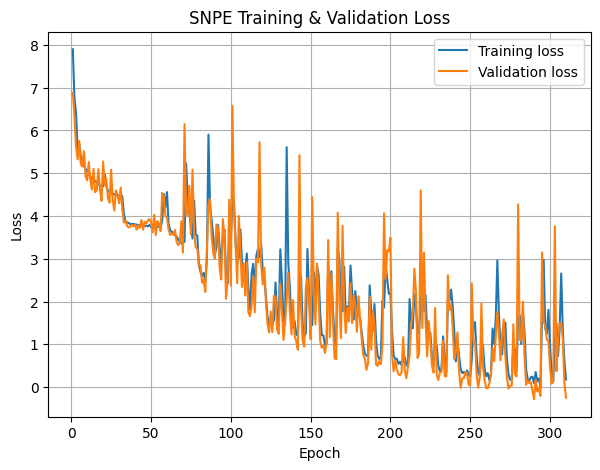

In [ ]:
summary = inference.summary
train_loss = summary["training_loss"]
val_loss = summary["validation_loss"]
epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, train_loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
density_estimator.to(device).eval()
posterior = inference.build_posterior(density_estimator)

In [ ]:
# === TEST DISTRIBUTION (fixed Normal) ===
# Choose means/STD you want the NPE to recover
mu_true = torch.tensor([0.95, 0.30, 1700.0], dtype=torch.float32, device=device)
std_true = torch.tensor([0.10, 0.08, 120.0], dtype=torch.float32, device=device)

# Safety: clamp to prior support to avoid OOD simulator inputs
prior_low = prior.base_dist.low.to(device)
prior_high = prior.base_dist.high.to(device)

N_test = 1000  # number of test items
S_post = 500  # posterior samples per test item

In [ ]:
# Sample test thetas from fixed Normal (independent dims), clamp to prior box
with torch.no_grad():
    theta_test = (mu_true + std_true * torch.randn(N_test, 3, device=device)).clamp(
        prior_low, prior_high
    )
theta_test_cpu = theta_test.detach().cpu()


# Simulate x_test in manageable batches using your simulator()
def simulate_batch_thetas(theta_cpu, batch=64):
    xs = []
    for i in range(0, len(theta_cpu), batch):
        xb = simulator(theta_cpu[i : i + batch])  # returns CPU tensor (B, T, D_in)
        xs.append(xb)
    return torch.cat(xs, dim=0)


x_test = simulate_batch_thetas(theta_test_cpu)  # (N_test, T_event, D_in), CPU
assert x_test.shape[1] == T_event and x_test.shape[2] == D_in

In [ ]:
# For each x_i, draw S_post samples from p(θ|x_i); aggregate across test set.
all_samples = []
with torch.no_grad():
    for i in range(N_test):
        xi = x_test[i : i + 1].to(device)  # (1,T,D)
        samp = posterior.sample((S_post,), x=xi)  # (S_post, 3)
        all_samples.append(samp.cpu())
all_samples = torch.cat(all_samples, dim=0).numpy()  # (N_test*S_post, 3)
print("Aggregated posterior samples:", all_samples.shape)

  0%|          | 0/500 [00:00<?, ?it/s]

/software/NHKB22930/nhkbarit/conda_envs/npe/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:1410.)
  result = _VF.gru(


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

                    accepted. It may take a long time to collect the remaining
                    500 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.


  0%|          | 0/500 [00:00<?, ?it/s]

                    accepted. It may take a long time to collect the remaining
                    500 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.


KeyboardInterrupt: 

In [35]:
# all_samples = torch.cat(all_samples, dim=0).numpy()  # (N_test*S_post, 3)
# print("Aggregated posterior samples:", all_samples.shape)

Aggregated posterior samples: (293500, 3)


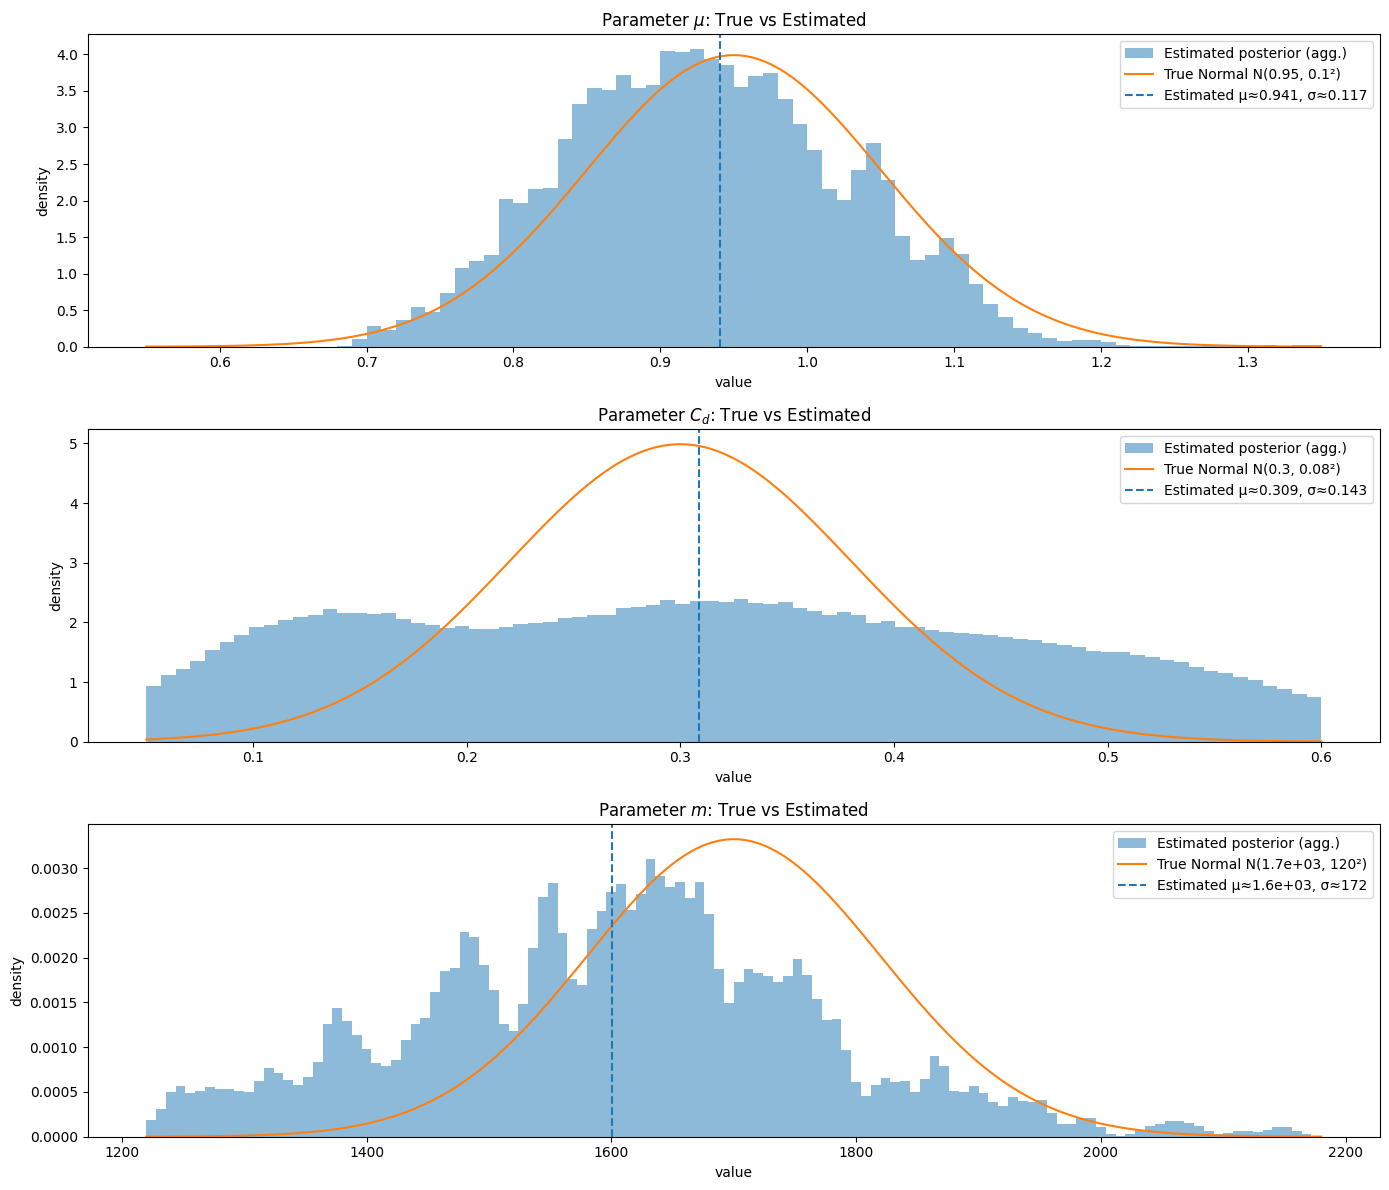

In [ ]:
names = [r"$\mu$", r"$C_d$", r"$m$"]
K = all_samples.shape[0]


def normal_pdf(x, m, s):
    return (1.0 / (s * sqrt(2 * pi))) * np.exp(-0.5 * ((x - m) / s) ** 2)


plt.figure(figsize=(14, 4 * 3))

for d in range(3):
    ax = plt.subplot(3, 1, d + 1)

    # histogram (estimated posterior, aggregated)
    vals = all_samples[:, d]
    # choose a reasonable range around true mean ±4σ (clipped to prior)
    lo = max(float(prior_low[d].cpu()), float(mu_true[d].cpu() - 4 * std_true[d].cpu()))
    hi = min(
        float(prior_high[d].cpu()), float(mu_true[d].cpu() + 4 * std_true[d].cpu())
    )
    bins = 80 if d < 2 else 120  # a few more bins for mass
    ax.hist(
        vals,
        bins=bins,
        range=(lo, hi),
        density=True,
        alpha=0.5,
        label="Estimated posterior (agg.)",
    )

    # true Normal curve
    xs = np.linspace(lo, hi, 1000)
    ax.plot(
        xs,
        normal_pdf(xs, float(mu_true[d].cpu()), float(std_true[d].cpu())),
        label=f"True Normal N({float(mu_true[d]):.3g}, {float(std_true[d]):.3g}²)",
    )

    # empirical fit from estimated samples
    est_mean = float(np.mean(vals))
    est_std = float(np.std(vals, ddof=1))
    ax.axvline(
        est_mean, linestyle="--", label=f"Estimated μ≈{est_mean:.3g}, σ≈{est_std:.3g}"
    )

    ax.set_title(f"Parameter {names[d]}: True vs Estimated")
    ax.set_xlabel("value")
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Compare means/stds numerically
for d, nm in enumerate(names):
    est_mean = float(np.mean(all_samples[:, d]))
    est_std = float(np.std(all_samples[:, d], ddof=1))
    print(
        f"{nm}:  true μ={float(mu_true[d]):.4f}, true σ={float(std_true[d]):.4f}  |  "
        f"estimated μ≈{est_mean:.4f}, σ≈{est_std:.4f}"
    )

$\mu$:  true μ=0.9500, true σ=0.1000  |  estimated μ≈0.9406, σ≈0.1166
$C_d$:  true μ=0.3000, true σ=0.0800  |  estimated μ≈0.3087, σ≈0.1434
$m$:  true μ=1700.0000, true σ=120.0000  |  estimated μ≈1600.6010, σ≈171.7609


In [ ]:
df_real = pd.read_csv("../../data/measurements/Jeversen_2022_10_12_110132.csv")

In [12]:
df_real.columns

Index(['Unnamed: 0', 'Steer_Angle', 'Acc_Body_X', 'Acc_Body_Y', 'Acc_Body_Z',
       'Tire_Rate_FL', 'Tire_Rate_FR', 'Tire_Rate_RL', 'Tire_Rate_RR',
       'Rate_Body_X', 'Rate_Body_Y', 'Rate_Body_Z', 'Engine_Torque',
       'Gear_Transmission', 'Break_Pressure', 'RCS1', 'RCS2', 'Rain', 'Temp',
       'INS_Vel_Hor_X_POI1', 'INS_Vel_Hor_Y_POI1', 'INS_Vel_Hor_Z_POI1',
       'GNSS_Lat_Abs', 'GNSS_Long_Abs', 'GNSS_Height', 'INS_Height_POI1',
       'INS_Lat_Abs_POI1', 'INS_Long_Abs_POI1', 'INS_Roll', 'INS_Pitch',
       'INS_Yaw', 'GNSS_Vel_Frame_X', 'GNSS_Vel_Frame_Y', 'GNSS_Vel_Frame_Z',
       'INS_Vel_Body_X', 'INS_Vel_Body_Y', 'INS_Vel_Body_Z'],
      dtype='object')

In [ ]:
def prep_x_obs_from_df(
    df,
    start_idx: int,
    T: int,
    *,
    rate_body_z_in_deg_s: bool = True,
    tire_rates_in_rpm: bool = False,
    vel_body_in_kmh: bool = False,
):
    """
    Build observation vector y_t from the CSV in the same format
    as the simulator output:

      [ yaw_rate, v_x, v_y, a_x, a_y, ω_FL, ω_FR, ω_RL, ω_RR ]

    All returned in SI units (rad/s, m/s, m/s², rad/s).
    """
    i0, i1 = start_idx, start_idx + T  # i1 is exclusive

    # --- 1) yaw_rate (rad/s) ---
    yaw_rate = df.iloc[i0:i1]["Rate_Body_Z"].to_numpy(dtype=np.float32)
    if rate_body_z_in_deg_s:
        yaw_rate = yaw_rate * (np.pi / 180.0)  # deg/s -> rad/s

    # --- 2) body-frame velocities (m/s) from INS ---
    v_body_x = df.iloc[i0:i1]["INS_Vel_Body_X"].to_numpy(dtype=np.float32)
    v_body_y = df.iloc[i0:i1]["INS_Vel_Body_Y"].to_numpy(dtype=np.float32)
    if vel_body_in_kmh:
        v_body_x *= 1000.0 / 3600.0  # km/h -> m/s
        v_body_y *= 1000.0 / 3600.0

    # --- 3) body-frame accelerations (m/s²) ---
    a_body_x = df.iloc[i0:i1]["Acc_Body_X"].to_numpy(dtype=np.float32)
    a_body_y = df.iloc[i0:i1]["Acc_Body_Y"].to_numpy(dtype=np.float32)

    # --- 4) tire angular rates (rad/s) ---
    def get_tire(col):
        arr = df.iloc[i0:i1][col].to_numpy(dtype=np.float32)
        if tire_rates_in_rpm:
            arr = arr * (2.0 * np.pi / 60.0)  # rpm -> rad/s
        return arr

    tire_fl = get_tire("Tire_Rate_FL")
    tire_fr = get_tire("Tire_Rate_FR")
    tire_rl = get_tire("Tire_Rate_RL")
    tire_rr = get_tire("Tire_Rate_RR")

    # Stack into (T, 9)
    x_obs = np.stack(
        [
            yaw_rate,
            v_body_x,
            v_body_y,
            a_body_x,
            a_body_y,
            tire_fl,
            tire_fr,
            tire_rl,
            tire_rr,
        ],
        axis=1,
    )

    return torch.from_numpy(x_obs.astype(np.float32))

In [40]:
def make_controls_from_df(df, start_idx, T, *, steer_in_deg=True):
    i0, i1 = start_idx, start_idx + T
    steer = df.iloc[i0:i1]["Steer_Angle"].to_numpy(np.float32)
    if steer_in_deg:
        steer = np.deg2rad(steer)
    eng_t = df.iloc[i0:i1]["Engine_Torque"].to_numpy(np.float32)
    brk_t = df.iloc[i0:i1]["Break_Pressure"].to_numpy(
        np.float32
    )  # convert to brake torque units if needed!
    gear = df.iloc[i0:i1]["Gear_Transmission"].to_numpy(np.float32)
    return {
        "steer_ang": jnp.asarray(steer),
        "engine_torque": jnp.asarray(eng_t),
        "break_torque": jnp.asarray(brk_t),
        "gear_transmission": jnp.asarray(gear),
    }

In [ ]:
T_raw = T_event * DECIMATE
N = len(df_real)


def pick_start_idx_len_safe(
    df, T_raw, *, prefer_low_brake=True, thresh=5.0, max_viol_frac=0.01
):
    """
    Returns a valid start index in [0, N-T_raw].
    - If prefer_low_brake: choose the window with the most samples below 'thresh'.
      Accept if violations <= max_viol_frac * T_raw; otherwise fall back to the last window.
    - If df has fewer than T_raw rows in total, raise a clear error.
    """
    N = len(df)
    if N < T_raw:
        raise AssertionError(
            f"CSV has only {N} rows, but {T_raw} are required for this trained model "
            f"(T_seg={T_seg}, DECIMATE={DECIMATE}). "
            f"Use a longer CSV, or retrain with a smaller T_seg."
        )

    if prefer_low_brake:
        brk = df["Break_Pressure"].to_numpy(np.float32)
        ok = (brk < thresh).astype(np.int32)
        # moving sum of 'ok' over length T_raw
        win = np.convolve(ok, np.ones(T_raw, dtype=np.int32), mode="valid")
        best_idx = int(np.argmax(win))
        violations = int(T_raw - win[best_idx])
        if violations <= int(max_viol_frac * T_raw):
            return best_idx

    # Fallback: last possible valid window
    return N - T_raw


# Pick a valid window (prefers low brake but never overflows)
start_idx = pick_start_idx_len_safe(
    df_real, T_raw, prefer_low_brake=True, thresh=5.0, max_viol_frac=0.01
)

print(f"[eval window] start_idx={start_idx}, rows={T_raw}, total_rows={N}")

# 1) Observations (9 channels) at raw rate
x_obs_raw = prep_x_obs_from_df(
    df_real,
    start_idx=start_idx,
    T=T_raw,
    rate_body_z_in_deg_s=True,
    tire_rates_in_rpm=False,
)  # (T_raw, 9) torch.float32

# 2) Controls (4 channels) at raw rate
controls_real = make_controls_from_df(df_real, start_idx, T_raw, steer_in_deg=True)
c_real = np.asarray(controls_to_array(controls_real))  # (T_raw, 4) np.float32

# # 3) Reset flag at raw rate
# r_flag = np.zeros((T_raw, 1), np.float32)
# r_flag[0, 0] = 1.0

# 4) Concat in the SAME order as training: [obs || controls]
x_concat = np.concatenate([x_obs_raw.numpy(), c_real], axis=-1)  # (T_raw, D_in)

# 5) Apply the SAME decimation as used in training to reach T_event
if DECIMATE > 1:
    L = (x_concat.shape[0] // DECIMATE) * DECIMATE
    x_concat = x_concat[:L:DECIMATE]
assert x_concat.shape[0] == T_event and x_concat.shape[1] == D_in, (
    x_concat.shape,
    T_event,
    D_in,
)

x_obs_full = (
    torch.from_numpy(x_concat.astype(np.float32)).unsqueeze(0).to(device)
)  # (T_event, D_in)

# Condition posterior and sample
posterior = posterior.set_default_x(x_obs_full)

with torch.no_grad():
    samples = posterior.sample((4000,))  # (4000, 3)

[eval window] start_idx=165, rows=3000, total_rows=3165


  0%|          | 0/4000 [00:00<?, ?it/s]

/software/NHKB22930/nhkbarit/conda_envs/npe/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:1410.)
  result = _VF.gru(


In [43]:
θ_mean = samples.mean(0)
θ_lo = samples.quantile(0.05, dim=0)
θ_hi = samples.quantile(0.95, dim=0)

In [44]:
print("Posterior mean [μ, C_d, m]:", θ_mean.tolist())
print("90% CI low                 :", θ_lo.tolist())
print("90% CI high                :", θ_hi.tolist())

Posterior mean [μ, C_d, m]: [0.5624242424964905, 0.32009875774383545, 1301.7164306640625]
90% CI low                 : [0.5272738337516785, 0.17951346933841705, 1276.045166015625]
90% CI high                : [0.5937474966049194, 0.482988178730011, 1327.7889404296875]


In [ ]:
def decimate_controls_dict(ctrls, factor):
    if factor <= 1:
        return ctrls
    L = int(ctrls["steer_ang"].shape[0]) // factor * factor
    return {
        k: jnp.asarray(np.asarray(v)[:L:factor], dtype=jnp.float32)
        for k, v in ctrls.items()
    }


def simulate_y_batch_for_thetas(theta_batch_np, controls_dec):
    """theta_batch_np: (K,3) float32 numpy → y_batch: (K, T_event, OBS_D)"""
    p_batch = jnp.asarray(theta_batch_np, dtype=jnp.float32)
    state0 = jnp.zeros(10, jnp.float32)

    def one(p):
        # rollout_with_states returns (state_seq, y_seq); take y_seq
        return rollout_with_states(p, controls_dec, state0=state0)[1]

    # vectorize over theta; jit compiles once for the given shapes
    y_batch = jax.jit(jax.vmap(one, in_axes=(0,)))(p_batch)  # (K, T, d)
    return np.asarray(y_batch, np.float32)

In [ ]:
def w2_sequence_vs_real(posterior, x_obs_full, controls_real, K=400, decimate=DECIMATE):
    # Real observations only (exclude controls): (T_event, OBS_D)
    y_real = x_obs_full[0, :, :OBS_D].cpu().numpy().astype(np.float32)
    y_real_n = norm_obs_only(y_real)

    ctrls_dec = decimate_controls_dict(controls_real, decimate)
    with torch.no_grad():
        thetas = posterior.sample((K,)).cpu().numpy().astype(np.float32)
    y_batch = simulate_y_batch_for_thetas(thetas, ctrls_dec)

    y_batch_n = norm_obs_only(y_batch)
    diffs = y_batch_n - y_real_n[None]

    w2_sq = np.mean(np.sum(diffs**2, axis=(1, 2)))
    return float(np.sqrt(w2_sq))

In [47]:
w2 = w2_sequence_vs_real(
    posterior, x_obs_full, controls_real, K=1000, decimate=DECIMATE
)
print("W2 (sequence vs real):", w2)

  0%|          | 0/1000 [00:00<?, ?it/s]

W2 (sequence vs real): 2221.083984375


In [ ]:
with torch.no_grad():
    θ_one = posterior.sample((1,), x=x_obs_full).cpu().numpy().astype(np.float32)

ctrls_dec = decimate_controls_dict(controls_real, DECIMATE)
y_sim_states, y_sim_obs = rollout_with_states(
    jnp.asarray(θ_one[0]), ctrls_dec, state0=jnp.zeros(STATE_DIM, jnp.float32)
)
y_sim_states = np.asarray(y_sim_states)
y_sim_obs = np.asarray(y_sim_obs)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
def plot_states_and_controls_comparison(
    states_sim,
    ctrls_sim,
    dt,
    *,
    states_real=None,
    ctrls_real=None,
    title="State and Control Comparison (Sim vs Real)",
    ncols=3,
):
    """
    Compact grid plot for all state variables and controls (Sim vs Real).
    Uses physical state names instead of x0-x9.
    """

    T = states_sim.shape[0]
    t = np.arange(T) * dt

    # --- Actual physical state labels ---
    state_labels = [
        "geo_pos_x [m]",
        "geo_pos_y [m]",
        "yaw [rad]",
        "yaw_rate [rad/s]",
        "veh_vel_x [m/s]",
        "veh_vel_y [m/s]",
        "tire_rate_FL [rad/s]",
        "tire_rate_FR [rad/s]",
        "tire_rate_RL [rad/s]",
        "tire_rate_RR [rad/s]",
    ]

    n_states = states_sim.shape[1]
    n_ctrls = 4
    total_plots = n_states + n_ctrls

    # --- subplot layout
    ncols = max(1, ncols)
    nrows = int(np.ceil(total_plots / ncols))

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols, 2.4 * nrows), sharex=False
    )
    axes = np.array(axes).reshape(-1)
    fig.suptitle(title, fontsize=14, y=1.02)

    # --- State variables ---
    for i in range(n_states):
        ax = axes[i]
        ax.plot(t, states_sim[:, i], label="Sim", lw=1.5)
        if states_real is not None:
            ax.plot(t, states_real[:, i], label="Real", lw=1.0, alpha=0.8)
        ax.set_title(
            state_labels[i] if i < len(state_labels) else f"state_{i}", fontsize=9
        )
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(loc="best", fontsize=8)

    # --- Controls ---
    ctrl_keys = ["engine_torque", "break_torque", "steer_ang", "gear_transmission"]
    ctrl_labels = ["Engine Torque [Nm]", "Brake [arb]", "Steer Angle [deg]", "Gear"]

    for j, (k, label) in enumerate(zip(ctrl_keys, ctrl_labels)):
        idx = n_states + j
        if idx >= len(axes):
            break
        ax = axes[idx]
        c_sim = np.asarray(ctrls_sim[k])
        if "steer" in k:
            c_sim = np.rad2deg(c_sim)
        ax.plot(t, c_sim, label="Sim", lw=1.5)
        if ctrls_real is not None:
            c_real = np.asarray(ctrls_real[k])
            if "steer" in k:
                c_real = np.rad2deg(c_real)
            ax.plot(t, c_real, label="Real", lw=1.0, alpha=0.8)
        ax.set_title(label, fontsize=9)
        ax.grid(True, alpha=0.3)
        if j == 0:
            ax.legend(loc="best", fontsize=8)

    # --- Clean up unused axes
    for ax in axes[total_plots:]:
        ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

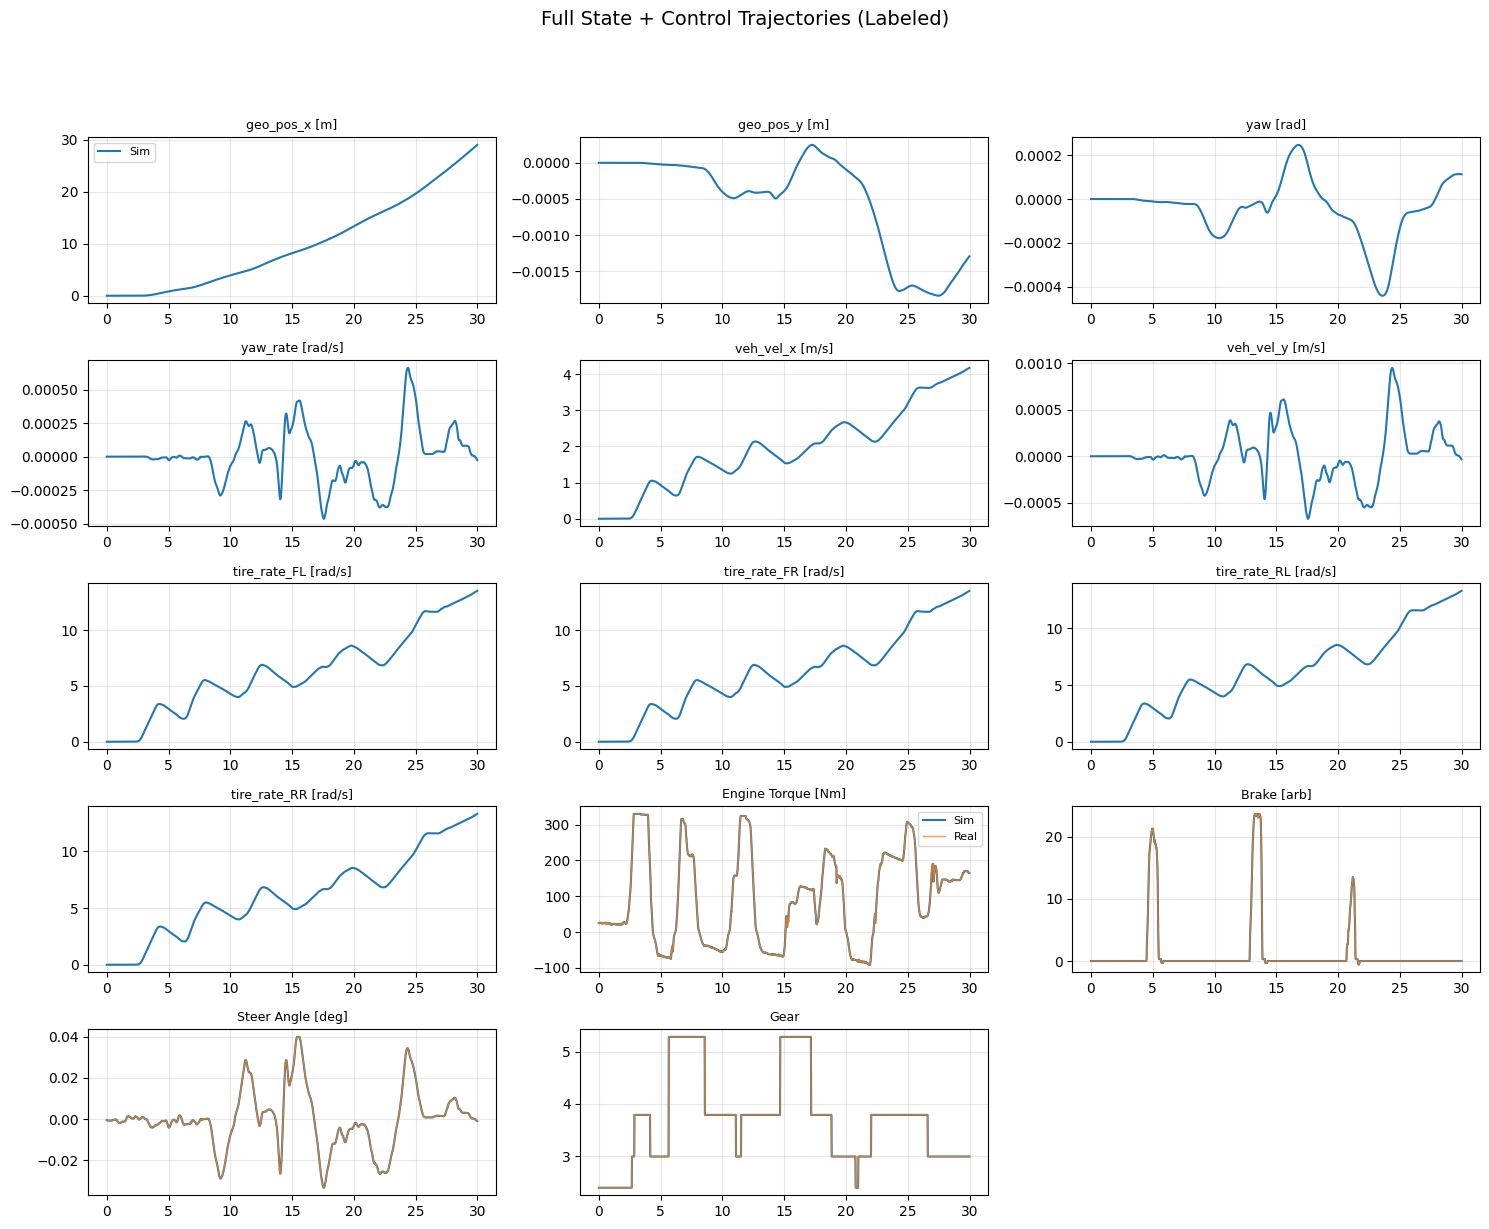

In [ ]:
plot_states_and_controls_comparison(
    states_sim=y_sim_states,
    ctrls_sim=ctrls_dec,
    dt=dt * DECIMATE,
    states_real=None,
    ctrls_real=decimate_controls_dict(controls_real, DECIMATE),
    title="Full State + Control Trajectories (Labeled)",
    ncols=3,
)

In [ ]:
obs_labels = [
    "yaw_rate [rad/s]",
    "v_body_x [m/s]",
    "v_body_y [m/s]",
    "a_body_x [m/s²]",
    "a_body_y [m/s²]",
    "tire_FL [rad/s]",
    "tire_FR [rad/s]",
    "tire_RL [rad/s]",
    "tire_RR [rad/s]",
]

T_event = x_obs_full.shape[1]
rmse_elem = w2 / np.sqrt(T_event * OBS_D)
print(f"Per-element RMSE (mixed units): {rmse_elem:.3f}")

with torch.no_grad():
    thetas = posterior.sample((400,), x=x_obs_full).cpu().numpy().astype(np.float32)

y_batch = simulate_y_batch_for_thetas(
    thetas, decimate_controls_dict(controls_real, DECIMATE)
)
diffs2 = (y_batch - x_obs_full[0, :, :OBS_D].cpu().numpy()[None]) ** 2
rmse_per_channel = np.sqrt(diffs2.mean(axis=(0, 1)))

print("\nPer-channel RMSEs:")
for label, val in zip(obs_labels, rmse_per_channel):
    print(f"  {label:<20}: {val:.4f}")

Per-element RMSE (mixed units): 19.116


  0%|          | 0/400 [00:00<?, ?it/s]

/software/NHKB22930/nhkbarit/conda_envs/npe/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:1410.)
  result = _VF.gru(



Per-channel RMSEs:
  yaw_rate [rad/s]    : 0.0008
  v_world_x [m/s]     : 8.4588
  v_world_y [m/s]     : 12.4636
  a_body_x [m/s²]     : 1.0134
  a_body_y [m/s²]     : 0.7949
  tire_FL [rad/s]     : 39.2701
  tire_FR [rad/s]     : 39.2701
  tire_RL [rad/s]     : 39.3452
  tire_RR [rad/s]     : 39.3452


In [54]:
def w2_importance_self_normalized(
    posterior, x_list, theta_true, K=1000, proposal_idx=0, device=None
):
    """
    W2^2 ≈ sum_i ŵ_i * ||θ_i - θ_true||^2, with importance weights
    ŵ_i ∝ ∏_{j≠proposal_idx} p(θ_i | x_j).
    Works best with a uniform prior (BoxUniform).
    """
    with torch.no_grad():
        # 1) Draw proposal samples from one expert posterior
        θ = posterior.sample((K,), x=x_list[proposal_idx]).to(device)  # (K, d)

        # 2) Log-weights = sum of log p(θ | x_j) over other experts
        logw = torch.zeros(K, device=device, dtype=θ.dtype)
        for j, xj in enumerate(x_list):
            if j == proposal_idx:
                continue
            logw += posterior.log_prob(θ, x=xj)  # each is (K,)

        # 3) Normalize weights stably
        logw = logw - logw.max()
        w = torch.exp(logw)
        w = w / (w.sum() + 1e-12)  # (K,)

        # 4) W2 components
        diffs = θ - theta_true  # (K, d)
        sqnorm = (diffs**2).sum(dim=1)  # (K,)
        w2_sq = (w * sqnorm).sum()  # scalar
        w2_per_dim = torch.sqrt((w.unsqueeze(1) * (diffs**2)).sum(dim=0))  # (d,)

        return torch.sqrt(w2_sq), w2_per_dim


x_list = [x_obs_full for _ in range(3)]
θ_true = prior.sample((1,)).squeeze(0).to(device)

with torch.no_grad():
    w2_val, w2_dim = w2_importance_self_normalized(
        posterior, x_list, θ_true, K=1000, proposal_idx=0, device=device
    )

print("W2 (IMP):", float(w2_val), " per-dim:", [float(z) for z in w2_dim])

  0%|          | 0/1000 [00:00<?, ?it/s]

W2 (IMP): 711.5867309570312  per-dim: [0.25887060165405273, 0.22940687835216522, 711.586669921875]


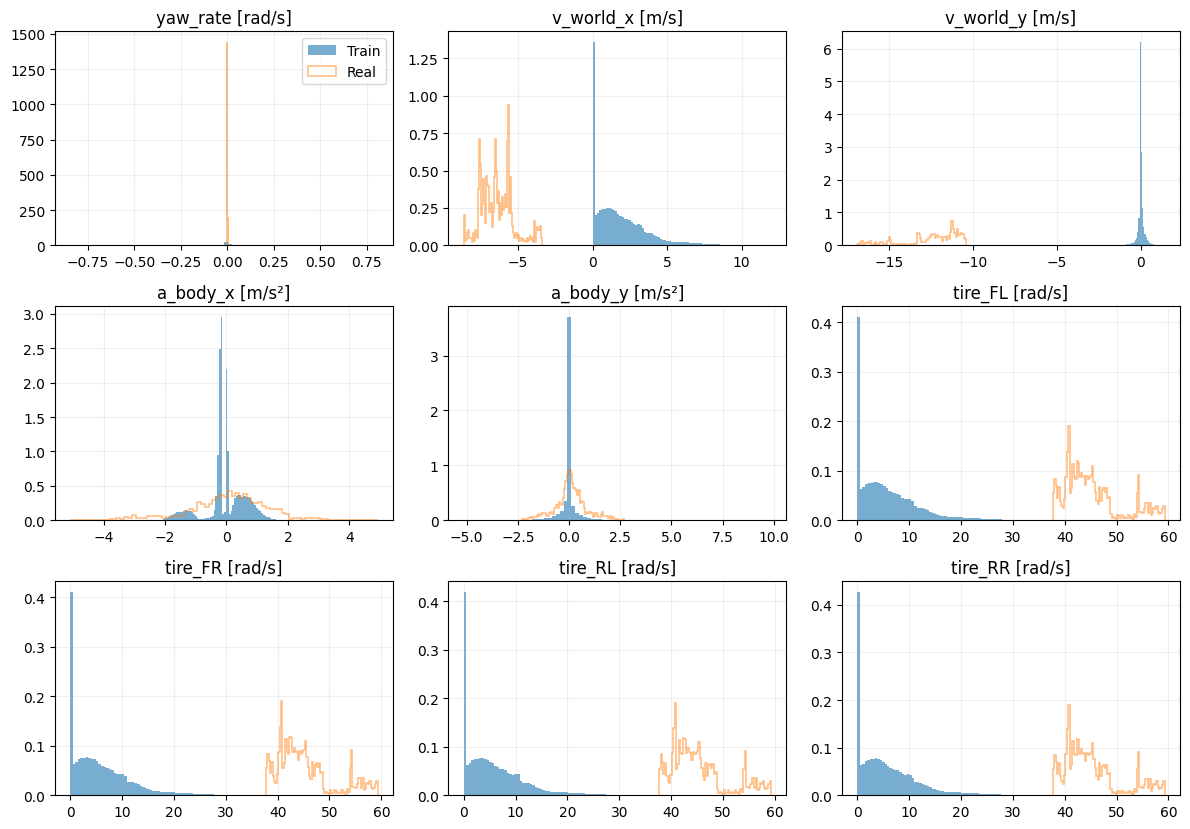

In [ ]:
# === Histogram coverage in observation "state space" =========================
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

obs_labels = [
    "yaw_rate [rad/s]",
    "v_world_x [m/s]",
    "v_world_y [m/s]",
    "a_body_x [m/s²]",
    "a_body_y [m/s²]",
    "tire_FL [rad/s]",
    "tire_FR [rad/s]",
    "tire_RL [rad/s]",
    "tire_RR [rad/s]",
]

# 1) Flatten training observations to (N*T, OBS_D)
# x: (N, T_event, D_in) where obs are the first OBS_D dims
train_obs = x[:, :, :OBS_D].detach().cpu().numpy().reshape(-1, OBS_D)

# 2) Real observations at model rate (already decimated to T_event)
real_obs = x_obs_full[0, :, :OBS_D].detach().cpu().numpy()


# ---- 1D histograms per dimension with real overlay --------------------------
def plot_obs_1d_hist(train_obs, real_obs, bins=80):
    D = train_obs.shape[1]
    cols = 3
    rows = int(np.ceil(D / cols))
    plt.figure(figsize=(4 * cols, 2.8 * rows))
    for d in range(D):
        ax = plt.subplot(rows, cols, d + 1)
        # Training distribution
        ax.hist(train_obs[:, d], bins=bins, density=True, alpha=0.6, label="Train")
        # Real overlay
        ax.hist(
            real_obs[:, d],
            bins=bins,
            density=True,
            alpha=0.5,
            histtype="step",
            linewidth=1.2,
            label="Real",
        )
        ax.set_title(obs_labels[d] if d < len(obs_labels) else f"obs_{d}")
        ax.grid(True, alpha=0.2)
        if d == 0:
            ax.legend()
    plt.tight_layout()
    plt.show()


plot_obs_1d_hist(train_obs, real_obs, bins=80)

# # 1) Per-dimension min/max coverage
# print("\nPer-dimension coverage (train range vs real range):")
# for d in range(OBS_D):
#     tr_min, tr_max = np.min(train_obs[:, d]), np.max(train_obs[:, d])
#     rl_min, rl_max = np.min(real_obs[:, d]), np.max(real_obs[:, d])
#     label = obs_labels[d] if d < len(obs_labels) else f"obs_{d}"
#     inside = (rl_min >= tr_min) and (rl_max <= tr_max)
#     print(f"  {label:>18}:  train[{tr_min: .4g}, {tr_max: .4g}] | real[{rl_min: .4g}, {rl_max: .4g}] | inside_all={inside}")

# # 2) For each 2D pair, fraction of real points that fall into non-empty train bins
# def fraction_real_in_train_bins(train_obs, real_obs, d1, d2, bins=80):
#     # Build 2D histogram for train
#     H, xedges, yedges = np.histogram2d(train_obs[:, d1], train_obs[:, d2], bins=bins)
#     # Bin each real point and test if it lands in a non-empty bin
#     x_idx = np.searchsorted(xedges, real_obs[:, d1], side='right') - 1
#     y_idx = np.searchsorted(yedges, real_obs[:, d2], side='right') - 1
#     valid = (x_idx >= 0) & (x_idx < H.shape[0]) & (y_idx >= 0) & (y_idx < H.shape[1])
#     hit = np.zeros_like(valid, dtype=bool)
#     hit[valid] = H[x_idx[valid], y_idx[valid]] > 0
#     return hit.mean()

# print("\n2D intersection: fraction of real samples inside non-empty train bins")
# for (d1, d2) in dims_2d:
#     frac = fraction_real_in_train_bins(train_obs, real_obs, d1, d2, bins=100)
#     l1 = obs_labels[d1] if d1 < len(obs_labels) else f"obs_{d1}"
#     l2 = obs_labels[d2] if d2 < len(obs_labels) else f"obs_{d2}"
#     print(f"  ({l1} , {l2}): {frac:.3f}")